In [246]:
import numpy as np
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.hrf import Optimise_HRF
from SensoriMotorPrediction.util import calc_R2
import seaborn as sb
import matplotlib.pyplot as plt
import os
import pandas as pd

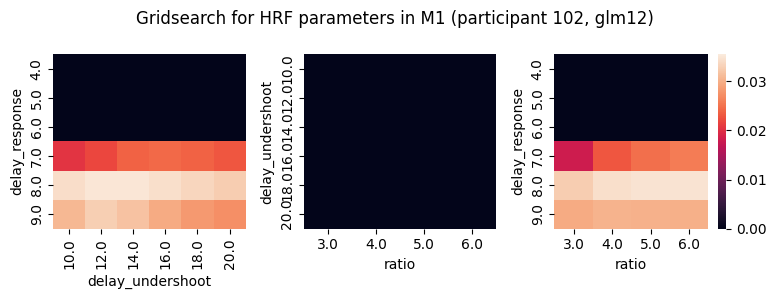

In [247]:
experiment = 'smp2'
sn = 102
H = 'L'
roi = 'M1'
glm = 12
gridsearch = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', 'gridsearch_hrf.tsv'), sep='\t')

pairs = [('delay_response', 'delay_undershoot'),
         ('delay_undershoot', 'ratio'),
         ('delay_response', 'ratio')]
vmin, vmax = 0, gridsearch.R_squared.max()

fig, axs = plt.subplots(1, 3, figsize=(8, 3))

for p, pair in enumerate(pairs):
    ax = axs[p]
    data = gridsearch.pivot_table(index=pair[0], columns=pair[1], values='R_squared', aggfunc='mean')
    sb.heatmap(data=data, ax=ax, vmin=vmin, vmax=vmax, cbar=True if p==2 else False)

fig.suptitle(f'Gridsearch for HRF parameters in {roi} (participant {sn}, glm{glm})')
fig.tight_layout()

plt.show()

['8.0', '14.0', '1.0', '1.0', '5.0', '0.0', '32.0']
R2=0.03549778870258247


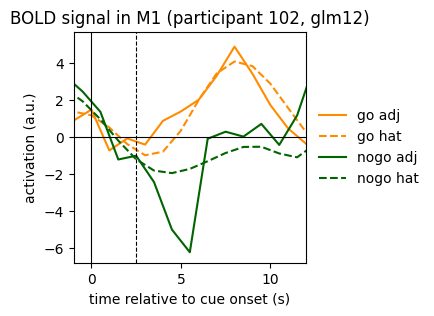

In [248]:
HRF = Optimise_HRF(sn=sn, glm=glm, H=H, roi=roi)
P = HRF.df[HRF.df.sn==sn].reset_index()['P'][0].split(',')
#P = [8, 18, 1, 1, 2, 0, 32]
y_hat, y_adj, y_cut_hat_go, y_cut_adj_go, y_cut_hat_nogo, y_cut_adj_nogo = HRF.manual(P, pre=3, post=16)
R2 = calc_R2(y_adj, y_hat)
print(P)
print(f'R2={R2}')

fig, ax = plt.subplots(figsize=(3, 3),)

tAx_go = np.arange(-3, 17)
tAx_nogo = tAx_go - 2.5

ax.plot(tAx_go, y_cut_adj_go.mean(axis=(0, -1)), color='darkorange', label='go adj')
ax.plot(tAx_go, y_cut_hat_go.mean(axis=(0, -1)), color='darkorange', ls='--', label='go hat')
ax.plot(tAx_nogo, y_cut_adj_nogo.mean(axis=(0, -1)), color='darkgreen', label='nogo adj')
ax.plot(tAx_nogo, y_cut_hat_nogo.mean(axis=(0, -1)), color='darkgreen', ls='--', label='nogo hat')

ax.axvline(0, color='k', ls='-', lw=.8)
ax.axvline(2.5, color='k', ls='--', lw=.8)
ax.axhline(0, color='k', ls='-', lw=.8)

ax.set_xlim((-1, 12))
ax.set_xlabel(None)
ax.set_ylabel('activation (a.u.)')
ax.set_xlabel('time relative to cue onset (s)')
ax.set_title(f'BOLD signal in {roi} (participant {sn}, glm{glm})')
ax.legend(frameon=False, bbox_to_anchor=(1, .5), loc='center left')
#ax.set_ylim((-2, 3))

plt.show()